# Аналитический отчёт: продажи Omega-3 на Ozon

## Период анализа
16 сентября 2025 — 15 сентября 2026

## Проблема клиента

Падение продаж началось в мае 2026 года. Доля магазина в нише 
«БАД жирные кислоты» упала с 0,9% в апреле до 0,3% в августе — 
потеря 67% рыночной позиции. При этом сама ниша не снижалась, 
а в августе даже выросла до 284,7 млн ₽. Конкуренты заняли 
освободившееся место.

## Причины

1. Сокращение ДРР (доли рекламных расходов) с 12,7% в марте 
до 5,5% в мае.
2. Падение конверсии из заказа в выкуп на 15,23 п.п.

## Рекомендации

1. Вернуть ДРР на уровень 10–12% — это восстановит показы и трафик
2. Удерживать цены — индекс цен уже «Супер-выгодный», 
   доп. скидки не нужны
3. Не сокращать расходы на рекламу в период пикового спроса

Месячная сводка:
  month  total_sales   avg_drr
2025-09       662501  9.933333
2025-10      1423105 13.193548
2025-11      1854520 10.566667
2025-12      1519122 10.679688
2026-01      1366314 12.177419
2026-02      1690675 10.910714
2026-03      1822171 12.685484
2026-04      1016779  9.166667
2026-05       936975  5.500000
2026-06       927099  6.858333
2026-07       939752  8.040323
2026-08      1359201  9.814516
2026-09       886863 10.850000


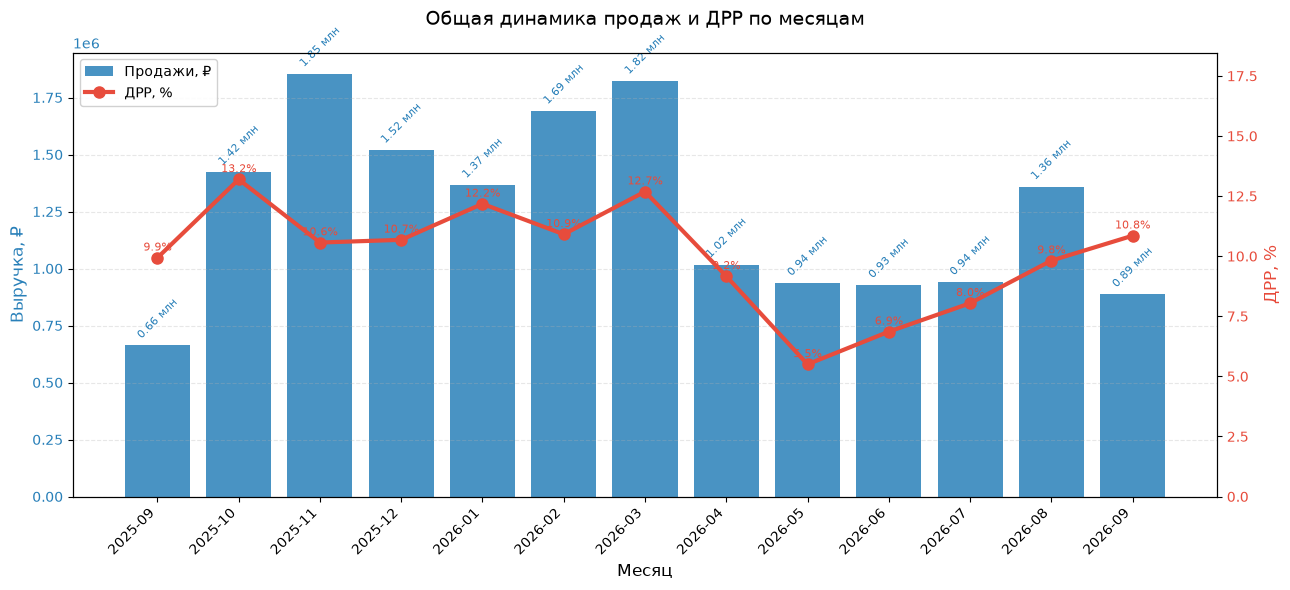

Шаг 2: график сохранён — step2_sales_drr_total.png


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Загрузка 
df = pd.read_csv('omega_sales_report/omega_sales_report_4.csv', sep=';', encoding='utf-8-sig')
df = df[df['Товары'].notna() & (df['Товары'].str.strip() != '')].copy()

# Очистка: деньги (убираем пробелы-разделители, без ₽)
def clean_money(series):
    s = series.astype(str)
    s = s.str.replace('\xa0', '', regex=False)
    s = s.str.replace(' ', '', regex=False)
    s = s.str.strip()
    s = s.str.replace(',', '.', regex=False)
    s = s.replace('#ДЕЛ/0!', '', regex=False)
    s = s.replace('nan', '', regex=False)
    s = s.replace('–', '', regex=False)
    return pd.to_numeric(s, errors='coerce')

# Очистка: проценты (убираем знак %)
def clean_percent(series):
    s = series.astype(str)
    s = s.str.replace('%', '', regex=False)
    s = s.str.replace('\xa0', '', regex=False)
    s = s.str.replace(' ', '', regex=False)
    s = s.str.strip()
    s = s.replace('#ДЕЛ/0!', '', regex=False)
    s = s.replace('nan', '', regex=False)
    s = s.replace('–', '', regex=False)
    return pd.to_numeric(s, errors='coerce')

df['sales_rub'] = clean_money(df['Сумма продаж'])
df['drr_pct'] = clean_percent(df['ДРР'])
df['ordered_qty'] = clean_money(df['Заказано товаров'])
df['sale_date'] = pd.to_datetime(df['День'], errors='coerce')
df = df.dropna(subset=['sale_date']).copy()
df['month'] = df['sale_date'].dt.to_period('M').astype(str)

# Короткие имена товаров
short_names = {
    'Омега-3 90%, рыбий жир 900 мг для сердца и сосудов, 60 капс.': 'Омега-3 90% (60 капс.)',
    'Омега-3 90%, рыбий жир 900 мг для сердца и сосудов, 30 капс.': 'Омега-3 90% (30 капс.)',
    'БАД Вкусная Омега-3 для детей и подростков со вкусом мультифрут, 150 капс.': 'Омега-3 для детей (150 капс.)',
    'БАД Вкусная Омега-3 для детей и подростков со вкусом мультифрукт, 150 капс.': 'Омега-3 для детей (150 капс.)',
    'Омега-3 35%, рыбий жир с ламинарией и витамином Е 60 шт.': 'Омега-3 35% с ламинарией (60 шт.)'
}
df['product_short'] = df['Товары'].map(short_names).fillna(df['Товары'])

# Месячная агрегация
monthly = df.groupby('month', as_index=False).agg(
    total_sales=('sales_rub', 'sum'),
    avg_drr=('drr_pct', 'mean')
).sort_values('month')

print("Месячная сводка:")
print(monthly.to_string(index=False))

# График
fig, ax1 = plt.subplots(figsize=(13, 6))

# Столбцы — продажи
bars = ax1.bar(monthly['month'], monthly['total_sales'], color='#2980b9', alpha=0.85, label='Продажи, ₽')
ax1.set_xlabel('Месяц', fontsize=12)
ax1.set_ylabel('Выручка, ₽', fontsize=12, color='#2980b9')
ax1.tick_params(axis='y', labelcolor='#2980b9')

for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, height + 20000,
             f'{height/1e6:.2f} млн', ha='center', va='bottom',
             fontsize=8, rotation=45, color='#2980b9')

# Линия — ДРР
ax2 = ax1.twinx()
ax2.plot(monthly['month'], monthly['avg_drr'], color='#e74c3c', marker='o',
         linewidth=3, markersize=8, label='ДРР, %')
ax2.set_ylabel('ДРР, %', fontsize=12, color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c')

# Безопасный лимит оси (защита от NaN/Inf)
drr_max = monthly['avg_drr'].max()
if pd.notna(drr_max) and drr_max > 0:
    ax2.set_ylim(0, drr_max * 1.4)
else:
    ax2.set_ylim(0, 20)

for i, val in enumerate(monthly['avg_drr']):
    if pd.notna(val):
        ax2.text(i, val + 0.3, f'{val:.1f}%', ha='center', fontsize=8, color='#e74c3c')

plt.title('Общая динамика продаж и ДРР по месяцам', fontsize=14, pad=20)
ax1.set_xticks(range(len(monthly)))
ax1.set_xticklabels(monthly['month'], rotation=45, ha='right')
ax1.grid(axis='y', alpha=0.3, linestyle='--')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', framealpha=0.9)

plt.tight_layout()
plt.savefig('step2_sales_drr_total.png', dpi=150, bbox_inches='tight')
plt.show()
print("Шаг 2: график сохранён — step2_sales_drr_total.png")


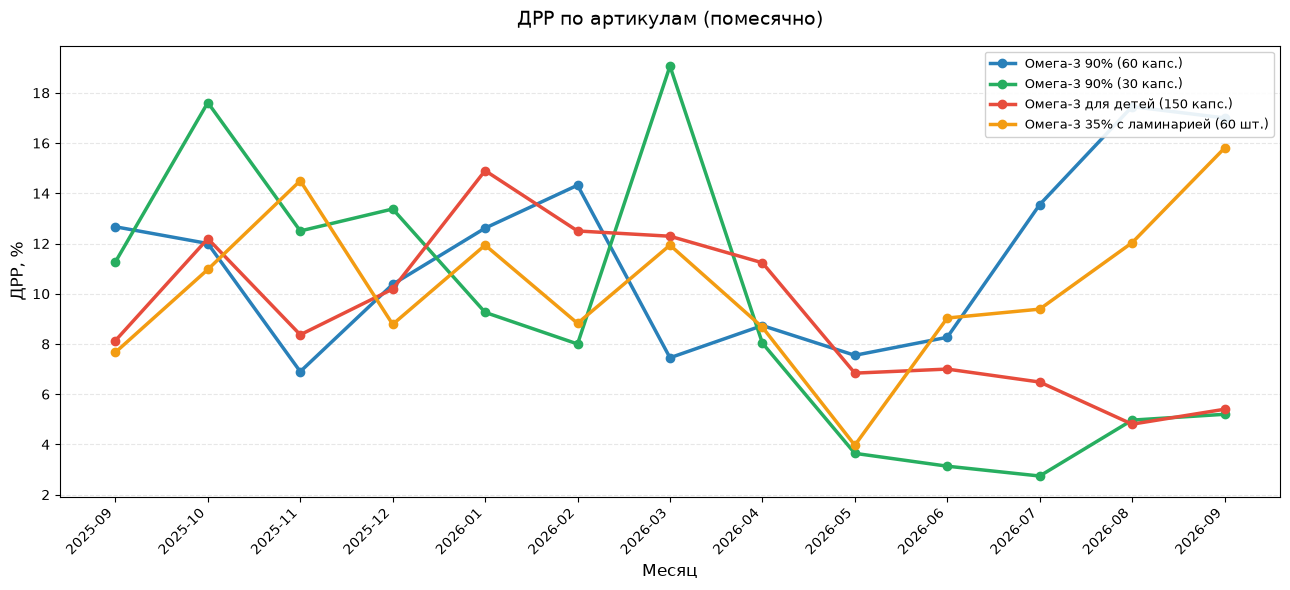

Шаг 3: график сохранён — step3_drr_by_product.png


In [40]:
colors = {
    'Омега-3 90% (60 капс.)': '#2980b9',
    'Омега-3 90% (30 капс.)': '#27ae60',
    'Омега-3 для детей (150 капс.)': '#e74c3c',
    'Омега-3 35% с ламинарией (60 шт.)': '#f39c12'
}
months_sorted = sorted(df['month'].unique())
products = list(df['product_short'].unique())

fig, ax = plt.subplots(figsize=(13, 6))

for product in products:
    data = df[df['product_short'] == product].groupby('month')['drr_pct'].mean().reindex(months_sorted)
    ax.plot(months_sorted, data.values, marker='o', linewidth=2.5, markersize=6,
            label=product, color=colors.get(product, 'gray'))

ax.set_title('ДРР по артикулам (помесячно)', fontsize=14, pad=15)
ax.set_xlabel('Месяц', fontsize=12)
ax.set_ylabel('ДРР, %', fontsize=12)
ax.set_xticks(range(len(months_sorted)))
ax.set_xticklabels(months_sorted, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig('step3_drr_by_product.png', dpi=150, bbox_inches='tight')
plt.show()
print("Шаг 3: график сохранён — step3_drr_by_product.png")


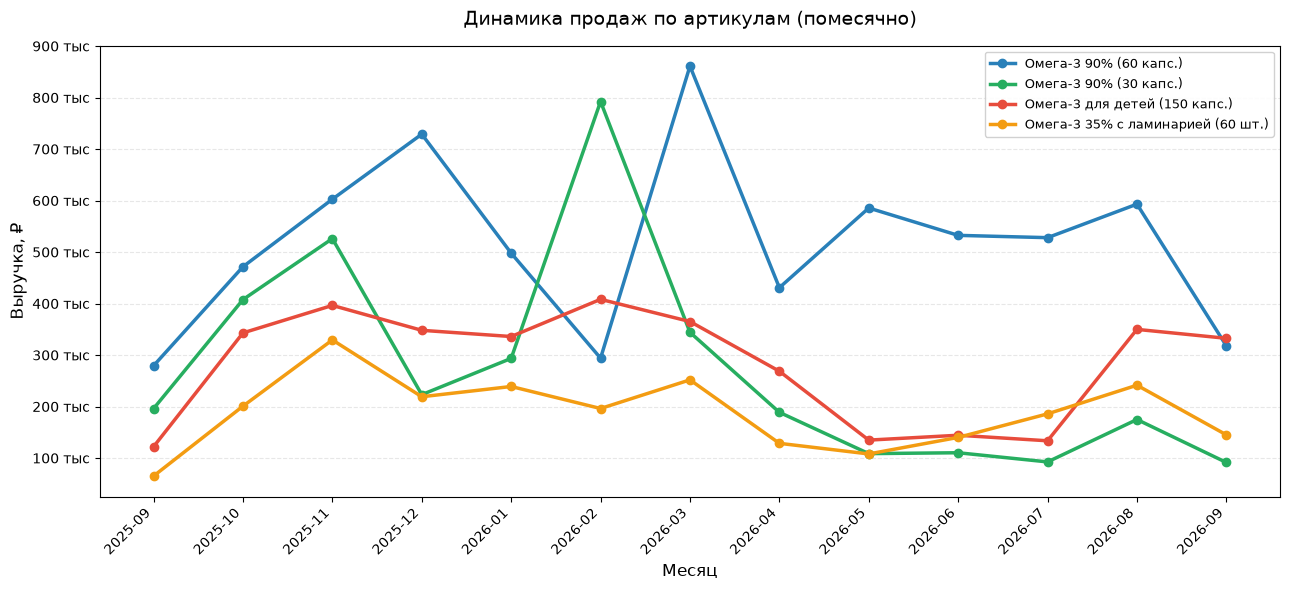

Шаг 4: график сохранён — step4_sales_by_product.png


In [41]:
fig, ax = plt.subplots(figsize=(13, 6))

for product in products:
    data = df[df['product_short'] == product].groupby('month')['sales_rub'].sum().reindex(months_sorted, fill_value=0)
    ax.plot(months_sorted, data.values, marker='o', linewidth=2.5, markersize=6,
            label=product, color=colors.get(product, 'gray'))

ax.set_title('Динамика продаж по артикулам (помесячно)', fontsize=14, pad=15)
ax.set_xlabel('Месяц', fontsize=12)
ax.set_ylabel('Выручка, ₽', fontsize=12)
ax.set_xticks(range(len(months_sorted)))
ax.set_xticklabels(months_sorted, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f} тыс'))

plt.tight_layout()
plt.savefig('step4_sales_by_product.png', dpi=150, bbox_inches='tight')
plt.show()
print("Шаг 4: график сохранён — step4_sales_by_product.png")


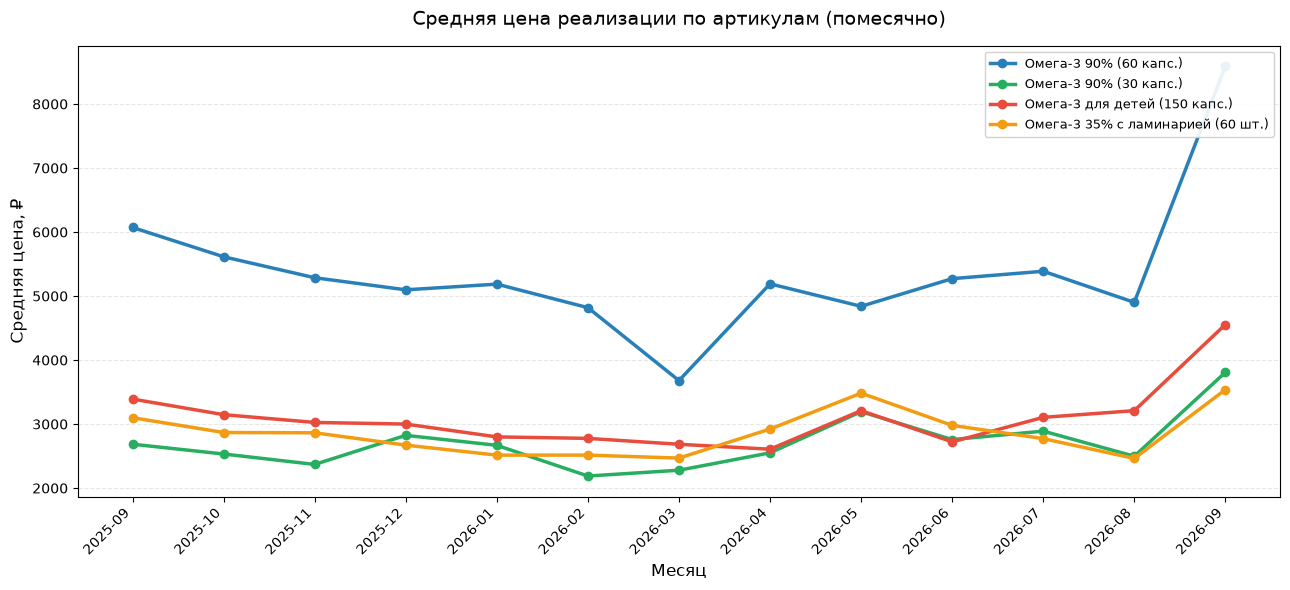

Шаг 5: график сохранён — step5_avg_price_by_product.png


In [42]:
fig, ax = plt.subplots(figsize=(13, 6))

for product in products:
    data = df[df['product_short'] == product].groupby('month').apply(
        lambda g: g['sales_rub'].sum() / g['ordered_qty'].sum() if g['ordered_qty'].sum() > 0 else np.nan
    ).reindex(months_sorted)
    ax.plot(months_sorted, data.values, marker='o', linewidth=2.5, markersize=6,
            label=product, color=colors.get(product, 'gray'))

ax.set_title('Средняя цена реализации по артикулам (помесячно)', fontsize=14, pad=15)
ax.set_xlabel('Месяц', fontsize=12)
ax.set_ylabel('Средняя цена, ₽', fontsize=12)
ax.set_xticks(range(len(months_sorted)))
ax.set_xticklabels(months_sorted, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig('step5_avg_price_by_product.png', dpi=150, bbox_inches='tight')
plt.show()
print("Шаг 5: график сохранён — step5_avg_price_by_product.png")


═══ Воронка ДО падения (сен 2025 — апр 2026) ═══
  Показы                  1,994,584
  Уникальные
посетители    1,356,341
  Визиты
карточки            70,313
  Добавления
в корзину        8,416
  Заказы                      3,598

═══ Воронка ПОСЛЕ падения (май — сен 2026) ═══
  Показы                    635,431
  Уникальные
посетители      416,673
  Визиты
карточки            23,112
  Добавления
в корзину        3,118
  Заказы                      1,282

═══ Конверсии между этапами ═══
Этап                            ДО    ПОСЛЕ        Δ
Показы → Уникальные
посетители    68.0%    65.6%    -2.4пп
Уникальные
посетители → Визиты
карточки     5.2%     5.5%    +0.4пп
Визиты
карточки → Добавления
в корзину    12.0%    13.5%    +1.5пп
Добавления
в корзину → Заказы          42.8%    41.1%    -1.6пп


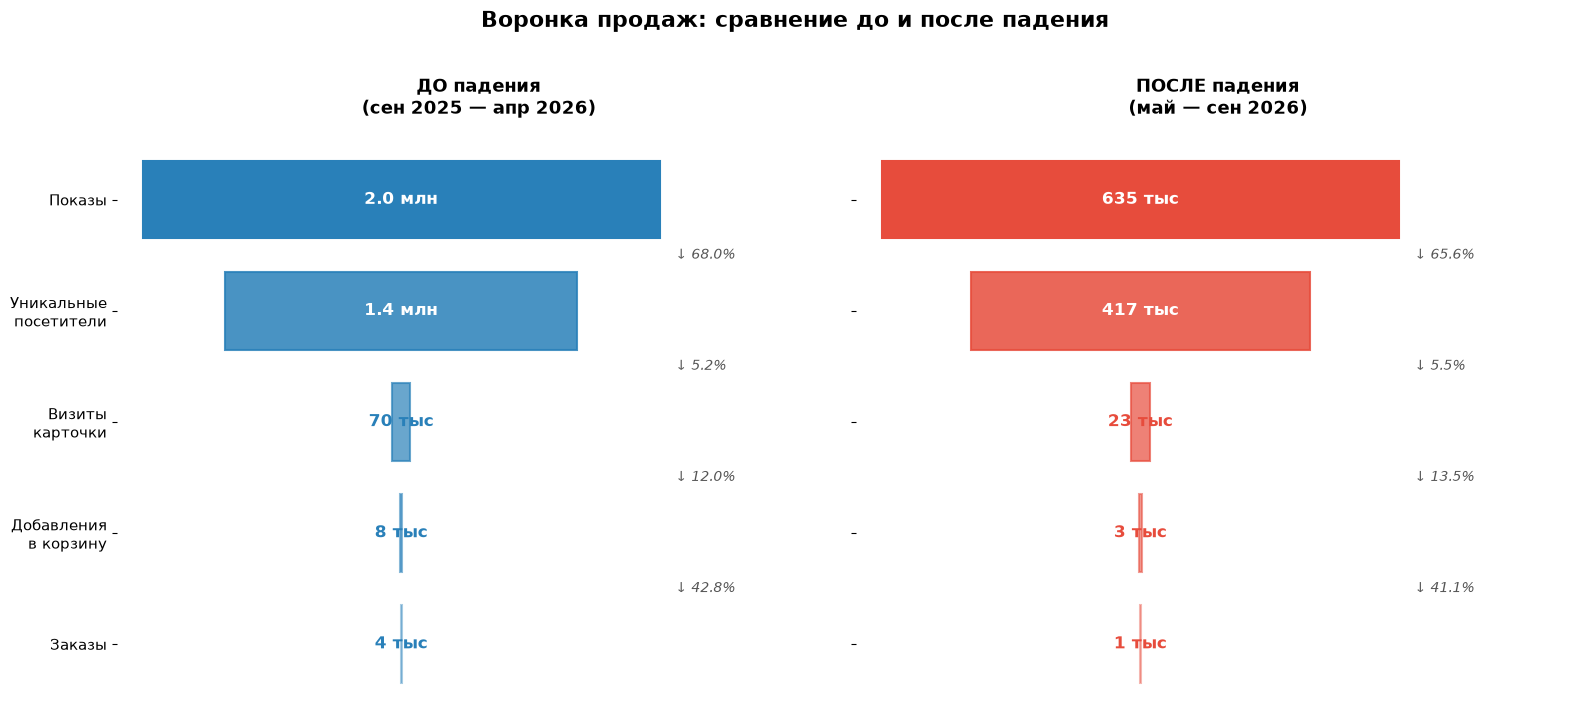


Шаг 6: график сохранён — step6_funnel.png


In [47]:
def clean_num(series):
    s = series.astype(str).str.replace('\xa0', '', regex=False).str.replace(' ', '', regex=False).str.strip()
    s = s.str.replace('%', '', regex=False)
    s = s.replace('#ДЕЛ/0!', '', regex=False).replace('nan', '', regex=False).replace('–', '', regex=False)
    return pd.to_numeric(s, errors='coerce')

df['sale_date'] = pd.to_datetime(df['День'], errors='coerce')
df = df.dropna(subset=['sale_date']).copy()

# Колонки воронки (точные имена из файла)
df['impressions'] = clean_num(df['Показы всего'])
df['visitors'] = clean_num(df['Уникальные\nпосетители, всего'])
df['card_visits'] = clean_num(df['Посещения карточки товара'])
df['cart_adds'] = clean_num(df['Добавления в\nкорзину всего'])
df['orders'] = clean_num(df['Заказано товаров'])

# Разделение на периоды: до падения / после
cutoff = pd.Timestamp('2026-05-01')
df_before = df[df['sale_date'] < cutoff]
df_after = df[df['sale_date'] >= cutoff]

stages = ['Показы', 'Уникальные\nпосетители', 'Визиты\nкарточки', 'Добавления\nв корзину', 'Заказы']

vals_before = [
    df_before['impressions'].sum(),
    df_before['visitors'].sum(),
    df_before['card_visits'].sum(),
    df_before['cart_adds'].sum(),
    df_before['orders'].sum()
]

vals_after = [
    df_after['impressions'].sum(),
    df_after['visitors'].sum(),
    df_after['card_visits'].sum(),
    df_after['cart_adds'].sum(),
    df_after['orders'].sum()
]

# Конверсии между этапами
def calc_conversions(vals):
    convs = []
    for i in range(len(vals) - 1):
        if vals[i] > 0:
            convs.append(vals[i + 1] / vals[i] * 100)
        else:
            convs.append(0)
    return convs

conv_before = calc_conversions(vals_before)
conv_after = calc_conversions(vals_after)

# Вывод в консоль
print("═══ Воронка ДО падения (сен 2025 — апр 2026) ═══")
for s, v in zip(stages, vals_before):
    print(f"  {s:20s} {v:>12,.0f}")
print()
print("═══ Воронка ПОСЛЕ падения (май — сен 2026) ═══")
for s, v in zip(stages, vals_after):
    print(f"  {s:20s} {v:>12,.0f}")
print()
print("═══ Конверсии между этапами ═══")
print(f"{'Этап':25s} {'ДО':>8s} {'ПОСЛЕ':>8s} {'Δ':>8s}")
for i, s in enumerate(stages[:-1]):
    cb = conv_before[i]
    ca = conv_after[i]
    delta = ca - cb
    print(f"{s} → {stages[i+1]:12s} {cb:>7.1f}% {ca:>7.1f}% {delta:>+7.1f}пп")

# График: две воронки рядом
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

for ax, vals, title, convs, color_main in [
    (axes[0], vals_before, 'ДО падения\n(сен 2025 — апр 2026)', conv_before, '#2980b9'),
    (axes[1], vals_after, 'ПОСЛЕ падения\n(май — сен 2026)', conv_after, '#e74c3c')
]:
    max_val = vals[0] if vals[0] > 0 else 1
    bar_height = 0.7

    for i, (stage, val) in enumerate(zip(stages, vals)):
        width = val / max_val
        y = len(stages) - 1 - i
        left = (1 - width) / 2

        ax.barh(y, width, height=bar_height, left=left,
                color=color_main, alpha=0.25 + 0.15 * (len(stages) - i),
                edgecolor=color_main, linewidth=1.5)

        label_color = 'white' if width > 0.25 else color_main
        if val >= 1e6:
            label_text = f'{val/1e6:.1f} млн'
        elif val >= 1e3:
            label_text = f'{val/1e3:.0f} тыс'
        else:
            label_text = f'{val:.0f}'

        ax.text(0.5, y, label_text, ha='center', va='center',
                fontsize=12, fontweight='bold', color=label_color)

        if i < len(stages) - 1:
            ax.text(1.03, y - 0.5, f'↓ {convs[i]:.1f}%', ha='left', va='center',
                    fontsize=10, color='#555', style='italic')

    ax.set_xlim(-0.05, 1.35)
    ax.set_yticks(range(len(stages)))
    ax.set_yticklabels(list(reversed(stages)), fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=15)
    ax.set_xticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.suptitle('Воронка продаж: сравнение до и после падения', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('step6_funnel.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nШаг 6: график сохранён — step6_funnel.png")


Месячная сводка конверсий (%):
         Показ → Заказ  Карточка → Корзина  Корзина → Заказ  Заказ → Выкуп
month                                                                     
2025-09           0.15                9.39            55.43          82.80
2025-10           0.15                8.93            54.90          85.35
2025-11           0.19                8.87            70.84          94.88
2025-12           0.16                9.84            60.94          89.07
2026-01           0.17               10.88            48.21          89.31
2026-02           0.21                9.17            60.73          83.00
2026-03           0.25                9.42            71.47          84.02
2026-04           0.18                8.69            59.49          80.11
2026-05           0.20                9.81            57.77          62.74
2026-06           0.24                8.67            67.73          66.19
2026-07           0.21                9.21            56.43          

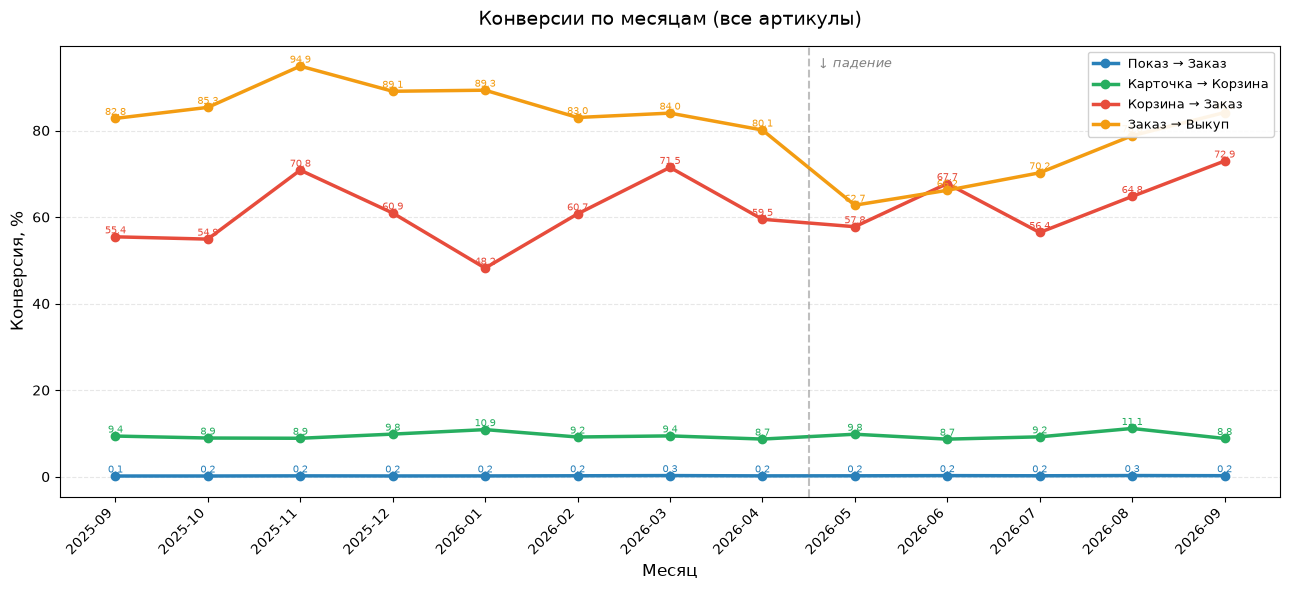


Шаг 7: график сохранён — step7_conversion_rates.png


In [46]:
def clean_percent(series):
    s = series.astype(str)
    s = s.str.replace('%', '', regex=False)
    s = s.str.replace(',', '.', regex=False)
    s = s.str.replace('\xa0', '', regex=False)
    s = s.str.replace(' ', '', regex=False)
    s = s.str.strip()
    s = s.replace('#ДЕЛ/0!', '', regex=False)
    s = s.replace('nan', '', regex=False)
    s = s.replace('–', '', regex=False)
    return pd.to_numeric(s, errors='coerce')

df['sale_date'] = pd.to_datetime(df['День'], errors='coerce')
df = df.dropna(subset=['sale_date']).copy()
df['month'] = df['sale_date'].dt.to_period('M').astype(str)

# Точные имена колонок конверсий (с переносами строк)
conv_cols = {
    'Конверсия из\nпоказа в заказ': 'Показ → Заказ',
    'Конверсия из\nкарточки в\nкорзину': 'Карточка → Корзина',
    'Конверсия из\nкорзины в заказ': 'Корзина → Заказ',
    'Конверсия из\nзаказа в выкуп': 'Заказ → Выкуп',
}

# Очищаем все колонки конверсий
for col in conv_cols:
    df[conv_cols[col]] = clean_percent(df[col])

months_sorted = sorted(df['month'].unique())

# Месячная агрегация — средняя конверсия по всем артикулам
monthly_conv = df.groupby('month')[list(conv_cols.values())].mean().reindex(months_sorted)

print("Месячная сводка конверсий (%):")
print(monthly_conv.round(2).to_string())

# Сравнение до / после падения
cutoff = pd.Timestamp('2026-05-01')
df['period'] = np.where(df['sale_date'] < cutoff, 'ДО', 'ПОСЛЕ')

print("\n═══ Средние конверсии: ДО vs ПОСЛЕ ═══")
print(f"{'Метрика':25s} {'ДО':>8s} {'ПОСЛЕ':>8s} {'Δ':>8s}")
for label in conv_cols.values():
    val_before = df[df['period'] == 'ДО'][label].mean()
    val_after = df[df['period'] == 'ПОСЛЕ'][label].mean()
    delta = val_after - val_before
    print(f"{label:25s} {val_before:>7.2f}% {val_after:>7.2f}% {delta:>+7.2f}пп")

# График: 4 линии конверсий по месяцам
colors_conv = {
    'Показ → Заказ': '#2980b9',
    'Карточка → Корзина': '#27ae60',
    'Корзина → Заказ': '#e74c3c',
    'Заказ → Выкуп': '#f39c12',
}

fig, ax = plt.subplots(figsize=(13, 6))

for label in conv_cols.values():
    data = monthly_conv[label]
    ax.plot(months_sorted, data.values, marker='o', linewidth=2.5, markersize=6,
            label=label, color=colors_conv[label])

    # Подписи над точками
    for i, val in enumerate(data.values):
        if pd.notna(val):
            ax.text(i, val + 0.8, f'{val:.1f}', ha='center', fontsize=7,
                    color=colors_conv[label])

# Вертикальная линия — граница падения (май 2026)
cutoff_idx = months_sorted.index('2026-04') + 0.5 if '2026-04' in months_sorted else None
if cutoff_idx is not None:
    ax.axvline(x=cutoff_idx, color='gray', linestyle='--', alpha=0.5, linewidth=1.5)
    ax.text(cutoff_idx + 0.1, ax.get_ylim()[1] * 0.95, '↓ падение',
            fontsize=9, color='gray', style='italic')

ax.set_title('Конверсии по месяцам (все артикулы)', fontsize=14, pad=15)
ax.set_xlabel('Месяц', fontsize=12)
ax.set_ylabel('Конверсия, %', fontsize=12)
ax.set_xticks(range(len(months_sorted)))
ax.set_xticklabels(months_sorted, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig('step7_conversion_rates.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nШаг 7: график сохранён — step7_conversion_rates.png")
